In [ ]:
#meta for myFiftyoneComputerVision 6/9/2025. On-Prem. POC AI Doc Vision. Part 0. Part 0. Doc Metadata+
# started from W ai-doc-visoin.ML_pipeline_0_data.ipynb

#infra: WLaptop + VSCode
#      env: default
#      confirmed Python 3.10.4
#      numpy 2.1.3, pandas 2.2.3, scikit-learn 1.6.1, matplotlib 3.10.0
#      pip 22.0.4, ipykernel 6.29.0, ipython 8.20.0
#fiftyone 1.4.0, fiftyone-brain 0.20.1, fiftyone_db 1.1.7
#umap-learn 0.5.7
#glob2 0.7


#Input: images in dir DOC_DATA/IMAGES_DOCS-5329
#       metadata+ file DOC_DATA/CUSTOMS_PORTAL_SAMPLE_W_DOC_PATH_W_SPLIT_W_BATCHES_02_24_2025.parquet
#Output: a complete metadata file DOC_DATA/df_docs-5329_metadata.parquet'

#previously in W ai-doc-visoin.ML_pipeline_0_data.ipynb
# 3/31/2025 0 DATA
#      Initial load
# 5/5/2025 0 DATA
#      found $issue0: `df_sample` mismatches `FILE_NAME` and `IMAGE_FILE_NAME` => dataset is wrong
# 5/5/2025 0 BUILD DF_SAMPLES (250 COUNT)
#      $fix0 `df_sample` correctly matches `FILE_NAME` and `IMAGE_FILE_NAME`
#next all PDFs instead of 250
# 5/7/2025 0 BUILD DF_SAMPLES (5329 COUNT)
#      Prepare `df_samples` to create 51dataset
#      from dir with images .jpg 
#      Images were already converted from .pdf in AML: aml_mlp_0_data & aml_mlp_1_prep_data + zipped to local machine
# 6/4/2025 MISC REORG
#      In mlp_0_data.ipynb, mlp_1_full.ipynb
#      Rename directories and files
#      IMAGES_DOCS-5329, DOC_DATA/df_docs-5329_metadata.parquet
#      Rerun this file? Y


#history
# 6/9/2025 FILE FOR EXTERNAL REF
#      No real data
#      Rerun this file? N


#$config $watch $error $fix $manual

In [ ]:
import sys
from glob import glob
import os

import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', 150)

#import csv

#vis
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6,4)

In [ ]:
#python version $my
print(sys.version)
print(np.__version__, pd.__version__)

In [ ]:
#----- $config -----
DATA_PATH = 'DOC_DATA'
IMAGES_PATH = 'IMAGES_DOCS-5329' # $manual

#in
DATA_FILE_METADATA = DATA_PATH + '/CUSTOMS_PORTAL_SAMPLE_W_DOC_PATH_W_SPLIT_W_BATCHES_02_24_2025.parquet' #$manual
#out
DATA_SAMPLES_OUT = DATA_PATH + '/df_docs-5329_metadata.parquet' #$manual



# POC AI-DOC-VISION
Questions to research:  
1. Can we cluster images of documents?

## 0. Load Data
Data types:  
1. PDF docs and their images  
2. Metadata about PDF docs

In [37]:
df_metadata = pd.read_parquet(DATA_FILE_METADATA)
print(df_metadata.shape)
print(df_metadata.info())
#df_metadata.head()

(5329, 69)
<class 'pandas.core.frame.DataFrame'>
Index: 5329 entries, 88 to 78072
Data columns (total 69 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CUSTOMER_NAME           5329 non-null   object        
 1   CUSTOMER_NO             5329 non-null   object        
 2   EI_REFERENCE            5329 non-null   object        
 3   BRANCH                  5329 non-null   object        
 4   ORIGIN                  5329 non-null   object        
 5   DEST                    5329 non-null   object        
 6   CARRIER_CODE            5324 non-null   object        
 7   CARRIER                 5329 non-null   object        
 8   TOTAL_QTY               5329 non-null   int64         
 9   TOTAL_QTY_UOM           5136 non-null   object        
 10  MASTERBILL              5324 non-null   object        
 11  MB                      5324 non-null   object        
 12  MB_QTY                  5329 non-null   

## 0a. EDA

In [38]:
df_metadata.columns

Index(['CUSTOMER_NAME', 'CUSTOMER_NO', 'EI_REFERENCE', 'BRANCH', 'ORIGIN',
       'DEST', 'CARRIER_CODE', 'CARRIER', 'TOTAL_QTY', 'TOTAL_QTY_UOM',
       'MASTERBILL', 'MB', 'MB_QTY', 'MB_QTY_UOM', 'FA', 'HOUSEBILL', 'HB',
       'HB_COUNT', 'HB_QTY', 'HB_QTY_UOM', 'CONTAINER_CO_REF', 'DXR', 'RLS',
       'SFT', 'IMPORTER_NAME', 'IMPORTER_NO', 'SHIPPER_NAME', 'SHIPPER_GCI',
       'CNEE_NAME', 'CNEE_NO', 'LOG', 'G_U_I_D', 'CREATION_TIME', 'CREATED_BY',
       'LAST_MODIFICATION_TIME', 'LAST_MODIFIED_BY', 'DOC_TYPE',
       'FILE_NAME_IMAGE', 'FILE_NAME_ANNOTATION', 'DESCRIPTION', 'FLAGS',
       'ANNOTATED', 'IMAGE_FILE_TYPE', 'CREATED_BY_NAME', 'MODIFIED_BY_NAME',
       'PAGE_COUNT', 'PRINTED', 'ROOT_ALIAS_IMAGE', 'ROOT_ALIAS_ANNOTATION',
       'SOURCE_', 'IMAGE_SIZE', 'EGUID', 'CHECKSUM', 'XREF',
       'DOCUMENT_DESCRIPTION', 'DOCUMENT_TYPE_NAME', 'DOC_IS_DATA_SOURCE',
       'MODE', 'DOC_CREATE_DOY', 'DOC_CREATE_WOY', 'DOC_CREATE_MOY',
       'SAMPLE_KEY', 'SAMPLE', 'FILE_NAME', 

In [ ]:
#interesting columns
df_metadata[['FILE_NAME', 'FILE_NAME_IMAGE', 'FILE_NAME_ANNOTATION', 'DESCRIPTION', 'IMAGE_FILE_TYPE', 'PAGE_COUNT', 'XREF']]

In [ ]:
#preview 1 file record
df_metadata[df_metadata['FILE_NAME'] == 'DTW_2190599317_HBL_mRrEQpjgSuYDAaKCYrFb1mYb601E5q1X1Ss.pdf'] #$manual

In [ ]:
print(df_metadata[df_metadata['FILE_NAME'] == 'DTW_2190599317_HBL_mRrEQpjgSuYDAaKCYrFb1mYb601E5q1X1Ss.pdf'])

In [ ]:
df_metadata['CUSTOMER_NAME'].value_counts().plot(kind="bar")

In [ ]:
df_metadata['CARRIER'].value_counts().plot(kind="bar")

In [ ]:
df_metadata['DOC_TYPE'].value_counts().plot(kind="bar")

In [ ]:
df_metadata['DOCUMENT_TYPE_NAME'].value_counts().plot(kind="bar")

Page count range:  1.0 40.0
PAGE_COUNT
1.0     2368
2.0     2323
3.0      246
10.0     109
5.0       92
4.0       88
7.0       41
6.0       23
8.0       21
20.0       3
16.0       3
9.0        3
13.0       2
40.0       1
27.0       1
12.0       1
26.0       1
24.0       1
18.0       1
11.0       1
Name: count, dtype: int64


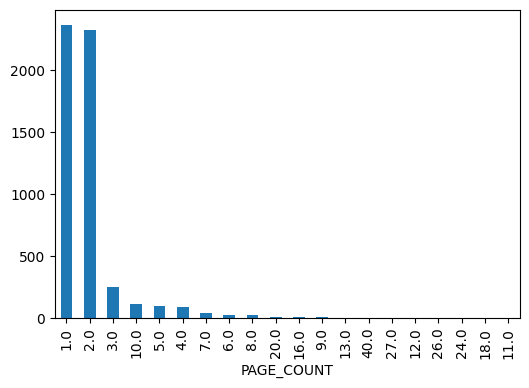

In [39]:
print("Page count range: ", df_metadata['PAGE_COUNT'].min(), df_metadata['PAGE_COUNT'].max())
print(df_metadata['PAGE_COUNT'].value_counts())

df_metadata['PAGE_COUNT'].value_counts().plot(kind="bar");

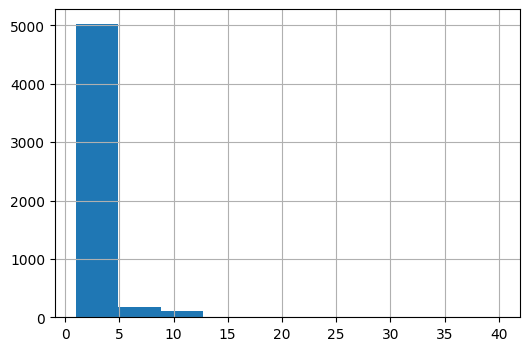

In [40]:
df_metadata['PAGE_COUNT'].hist(bins=10);

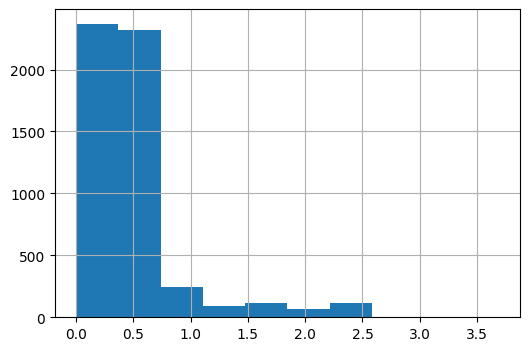

In [41]:
np.log(df_metadata['PAGE_COUNT']).hist(bins=10);

In [ ]:
#map doc types
df_metadata[['DOCUMENT_TYPE_NAME', 'DOC_TYPE']].value_counts()

## 1. Prep Data

### 1.0 Sort Metadata ds by `FILE_NAME'
#$issue0: `df_sample` mismatches `FILE_NAME` and `IMAGE_FILE_NAME` => dataset is wrong  
$fix0: sort files alphabetically to match files in a directory ($note: wrong if sorted by ASCII)

In [ ]:
df_metadata_sorted = df_metadata.copy()
df_metadata_sorted['FILE_NAME_UPPER'] = df_metadata_sorted['FILE_NAME'].str.upper() #$note: sort alphabetically not by ASCII)
df_metadata_sorted.sort_values(by='FILE_NAME_UPPER', inplace=True)

print(df_metadata_sorted.shape)
df_metadata_sorted.head()

### 1.1 Create Samples dataset
for loading into 51  
`Samples` is a term in 51 representing one datapoint (in this case one document)

In [ ]:
#load 1st pages only
all_images = glob(IMAGES_PATH+"/*_PAGE_0.jpg")
len(all_images)

all_images #list

In [ ]:
#create a tidy real/sample dataset
samples = []

# for image_name in all_images:
#     idx_start = image_name.index("\\") + 1
#     #idx_end = image_name.index(".")
#     samples.append(image_name[idx_start:])

samples = [image_name[image_name.index("\\") + 1:]for image_name in all_images]
samples

In [ ]:
samples_tidy = []
samples_tidy = [ sample_name[: (sample_name.index("_PAGE_0"))] + ".pdf" for sample_name in samples]
samples_tidy

In [ ]:
INCLUDE_COLS = ['FILE_NAME','CUSTOMER_NAME', 'BRANCH', 'ORIGIN', 'DEST', 
       'CARRIER', 'IMPORTER_NAME', 'SHIPPER_NAME', 'CNEE_NAME', 'CREATED_BY',
       'DOC_TYPE', 'DOCUMENT_DESCRIPTION', 'DOCUMENT_TYPE_NAME', 'DOC_IS_DATA_SOURCE',
       'MODE', 
       'DATA_SPLIT', 'XREF']

In [ ]:
df_samples = df_metadata_sorted.loc[df_metadata_sorted['FILE_NAME'].isin(samples_tidy), INCLUDE_COLS].copy()
print(df_samples.shape)

In [42]:
df_samples['IMAGE_FILE_NAME'] = samples
print(df_samples.shape)
print(df_samples.info())
#df_samples.head()

(5329, 20)
<class 'pandas.core.frame.DataFrame'>
Index: 5329 entries, 90 to 78071
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   FILE_NAME              5329 non-null   object
 1   CUSTOMER_NAME          5329 non-null   object
 2   BRANCH                 5329 non-null   object
 3   ORIGIN                 5329 non-null   object
 4   DEST                   5329 non-null   object
 5   CARRIER                5329 non-null   object
 6   IMPORTER_NAME          5329 non-null   object
 7   SHIPPER_NAME           5329 non-null   object
 8   CNEE_NAME              5329 non-null   object
 9   CREATED_BY             5329 non-null   object
 10  DOC_TYPE               5329 non-null   object
 11  DOCUMENT_DESCRIPTION   5329 non-null   object
 12  DOCUMENT_TYPE_NAME     5329 non-null   object
 13  DOC_IS_DATA_SOURCE     5329 non-null   object
 14  MODE                   5329 non-null   object
 15  DATA_SPLIT   

### 1.3 Validate
$issue0: noticed incorrect matches due to a different order of files in `IMAGES` directory  
Which means the dataset is wrong.  Fix it

In [ ]:
#check if head(5) sorted correctly
df_samples[['FILE_NAME', 'IMAGE_FILE_NAME', 'XREF']].head()

In [ ]:
df_metadata_sorted[245:250][['FILE_NAME', 'XREF']] 

In [ ]:
df_samples['IMAGE_FILE_NAME']

In [ ]:
# Check if file names are correct
df_samples['file_name_match'] = df_samples.apply(lambda row: row['XREF'] in row['FILE_NAME'], axis=1)
df_samples['image_file_name_match'] = df_samples.apply(lambda row: row['XREF'] in row['IMAGE_FILE_NAME'], axis=1)

df_samples[['FILE_NAME', 'IMAGE_FILE_NAME', 'XREF', 'file_name_match', 'image_file_name_match' ]].head()


In [43]:
#how many files match?
df_samples[['file_name_match', 'image_file_name_match' ]].sum()

file_name_match          5329
image_file_name_match    5329
dtype: int64

In [ ]:
#view mismatches
df_samples[df_samples['image_file_name_match'] == False][['FILE_NAME', 'IMAGE_FILE_NAME', 'XREF']]

In [ ]:
#check previous mismatches
df_samples.loc[3417:3422][['FILE_NAME', 'IMAGE_FILE_NAME']]

In [ ]:
df_samples[df_samples['image_file_name_match'] == False].shape[0], df_samples[df_samples['file_name_match'] == False].shape[0]

In [ ]:
#$note: IF need to compare order $manual
# for li in df_samples[['FILE_NAME', 'IMAGE_FILE_NAME']].to_numpy().tolist():
#     print(li)

In [ ]:
assert df_samples[df_samples['file_name_match'] == False].shape[0] == 0, "$watch File names must match"
assert df_samples[df_samples['image_file_name_match'] == False].shape[0] == 0, "$watch File names must match"

In [ ]:
#persist
df_samples.to_parquet(DATA_SAMPLES_OUT) #, index=False)

In [ ]:
mystop

## Xtra

In [ ]:
#$xtra $issue0 `df_sample` mismatches `FILE_NAME` and `IMAGE_FILE_NAME` => dataset is wrong
#previously: not all compare==True, to fix

#compare original f name to added f name
_idx_filename_substr = df_samples['FILE_NAME'].str.index('.pdf')
assert(_idx_filename_substr.min() == _idx_filename_substr.max())
#df_samples['FILE_NAME'].str[:_idx_filename_substr.min()]

_idx_imagefilename_substr = df_samples['IMAGE_FILE_NAME'].str.index('_PAGE_0.jpg')
assert(_idx_imagefilename_substr.min() == _idx_imagefilename_substr.max())
#df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]

#compare
df_samples['FILE_NAME'].str[:_idx_filename_substr.min()] == df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]


In [ ]:
#previously: find mismatches
print((df_samples['FILE_NAME'].str[:_idx_filename_substr.min()] != df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]).sum())
(df_samples['FILE_NAME'].str[:_idx_filename_substr.min()] != df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]).sum() == 0

In [ ]:
#previously: find mismatches
#a()
df_samples[df_samples['FILE_NAME'].str[:_idx_filename_substr.min()] != df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]]
#b)
match_idx = df_samples['FILE_NAME'].str[:_idx_filename_substr.min()] == df_samples['IMAGE_FILE_NAME'].str[:_idx_imagefilename_substr.min()]
match_idx[match_idx==False]